In [131]:
import numpy as np
from matplotlib.colors import hsv_to_rgb
import matplotlib.pyplot as plt

In [132]:
base = "test_100_100"
odarr= np.fromfile(f"./data/{base}_1dmpi.magdir.bin", dtype=np.float32)
refarr= np.fromfile(f"./data/{base}.magdir.bin", dtype=np.float32)
rows = 100-2
columns = 100-2
print(rows * columns, rows * columns*2, refarr.shape, odarr.shape)
print(np.any(np.isnan(odarr)))


9604 19208 (19208,) (19208,)
False


In [133]:
def visualize_vector_field(mag, direction, h, w):
    """
    mag: 2D array of floats (0-255)
    direction: 2D array of floats (-pi to pi)
    """
    MAX_SOBEL_VALUE = np.sqrt(2) * 4 * 255 # when gx,gy = 255; technically over esimate
    mag = mag/MAX_SOBEL_VALUE*255
    
    mag = mag.reshape(h,w)

    direction = direction.reshape(h,w)
    
    # 1. Create an empty HSV image
    # Shape: (height, width, 3)
    hsv = np.zeros((h, w, 3), dtype=np.float32)
    
    # 2. Map Direction to Hue [0, 1]
    # We shift -pi...pi to 0...2pi, then normalize to 0...1
    hsv[..., 0] = (direction + np.pi) / (2 * np.pi)
    
    # 3. Set Saturation to maximum
    hsv[..., 1] = 1.0
    
    # 4. Map Magnitude to Value [0, 1]
    # Ensure it's clipped and normalized
    hsv[..., 2] = np.clip(mag, 0, 255) / 255.0
    
    # 5. Convert HSV to RGB for display
    rgb = hsv_to_rgb(hsv)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb)
    plt.title("Magnitude (Brightness) & Direction (Color)")
    plt.axis('off')
    plt.show()


In [134]:
mags = odarr[:(rows*columns)]
dirs = odarr[(rows*columns):(rows*columns*2)]
np.any(np.isnan(odarr))
print(odarr[:(rows*columns*2)])

[ 0.          0.          0.         ... -0.49066806 -1.3101939
 -3.1054637 ]


In [135]:
def gen(): 
    c = 0
    with np.printoptions(threshold=np.inf, precision=1):
        while True:
            r1 = odarr[c*rows:(c+1)*rows]
            r2 = refarr[c*rows:(c+1)*rows]
            print(c, end=", ")
            c+=1
            if np.all(np.isclose(r1, r2)): 
                continue
            else: 
                print(c)
                print(r1)
                print(r2)
                print(r1 - r2)
                yield
a = gen()

In [136]:
# next(a)

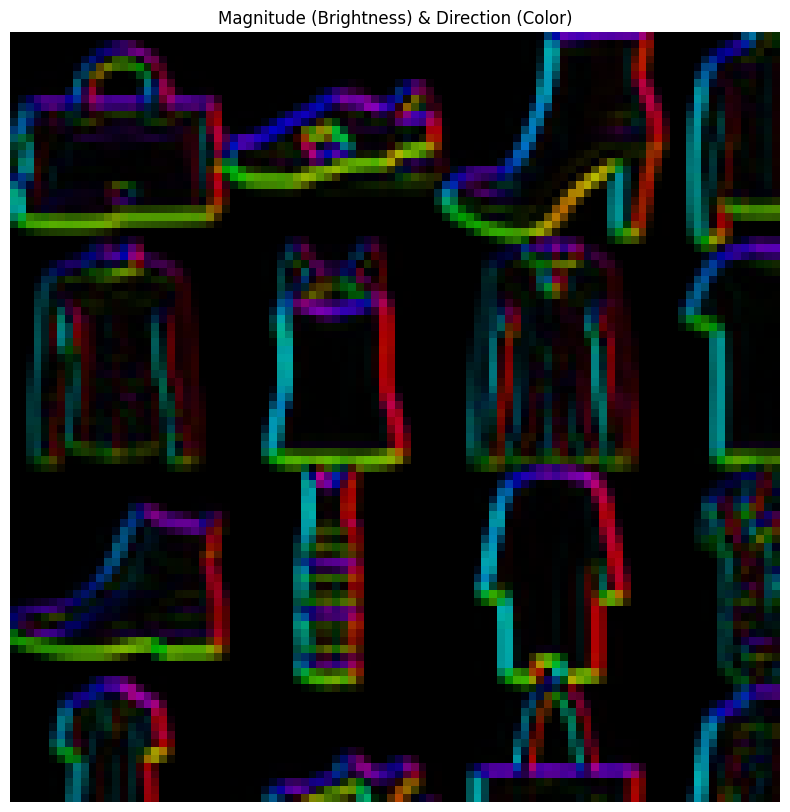

In [137]:
visualize_vector_field(mags, dirs, rows, 98)

In [138]:
np.any(np.isnan(odarr))

np.False_

In [139]:
ref_mags = refarr[:(rows*columns)]
ref_dirs = refarr[(rows*columns):]
print(ref_mags.min(), ref_mags.max())
print(ref_dirs.min(), ref_dirs.max())

0.0 1112.2311
-3.1385899 3.1415927


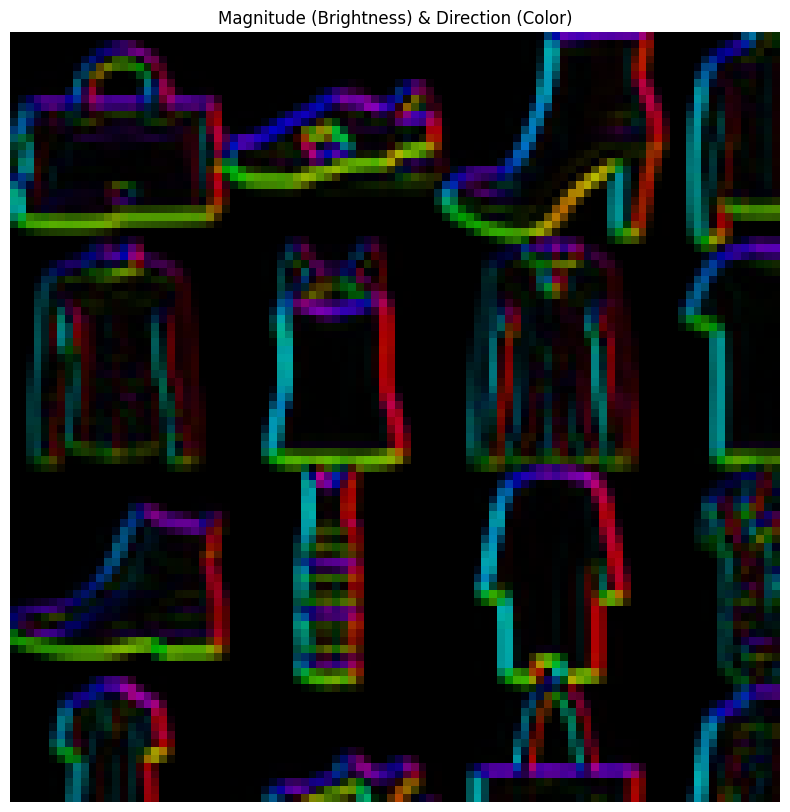

In [140]:
visualize_vector_field(ref_mags , ref_dirs, rows, columns)

In [141]:
mags[ref_mags != mags]

array([], dtype=float32)

In [142]:
ref_mags[ref_mags != mags]

array([], dtype=float32)

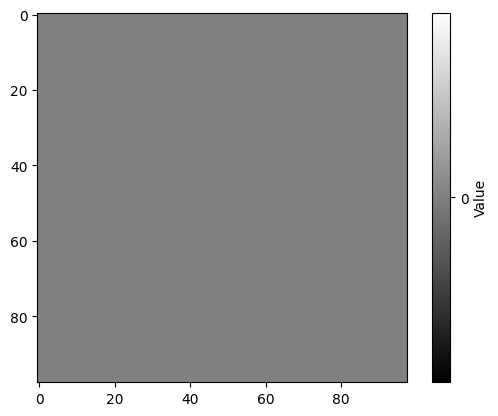

In [143]:
plt.imshow((ref_mags!=mags).reshape(rows,columns), cmap='gray')
plt.colorbar(ticks=[0, 1], label='Value')
plt.show()

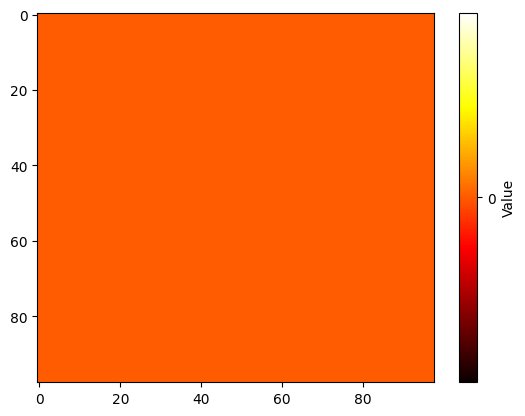

In [144]:
plt.imshow((mags-ref_mags).reshape(rows,columns), cmap='hot', aspect='auto')
plt.colorbar(ticks=[0, 1], label='Value')
plt.show()

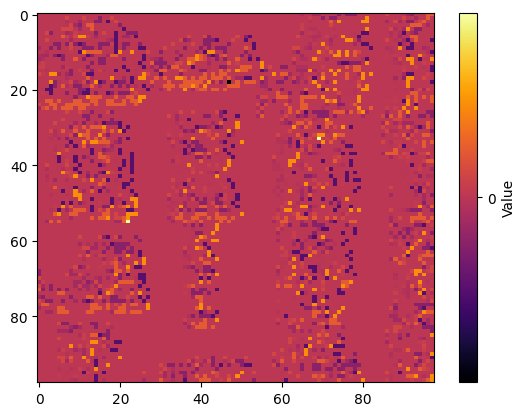

In [145]:
plt.imshow((dirs-ref_dirs).reshape(rows,columns), cmap='inferno', aspect='auto')
plt.colorbar(ticks=[0, 1], label='Value')
plt.show()